## Initial Premier League Data Analysis

This notebook contains exploratory data analysis results and visuals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_CSV = "../data/processed/epl_matches.csv"
COLS = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "season", "home_team_id", "away_team_id"]

In [2]:
matches = pd.read_csv(PROCESSED_CSV, parse_dates=["Date"], usecols=COLS)
matches.shape

# 3420 rows: 9 seasons x 380 matches each (2015-16 through 2023-24)

(3420, 9)

In [9]:
matches.head()

# fthg: home goals, ftag: away goals, ftr: result (H: home win, D: draw, A: away win)
# season: "15-16" through "23-24"; home/away_team_id: 0-indexed int (-1 for teams not in training)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,season,home_team_id,away_team_id
0,2015-08-08,Bournemouth,Aston Villa,0,1,A,15-16,2,1
1,2015-08-08,Chelsea,Swansea,2,2,D,15-16,7,25
2,2015-08-08,Everton,Watford,2,2,D,15-16,9,27
3,2015-08-08,Leicester,Sunderland,4,2,H,15-16,14,24
4,2015-08-08,Man United,Tottenham,1,0,H,15-16,17,26


In [10]:
matches.isna().sum()

# no nulls — dates already parsed and cleaned by data_cleaning.py
# unknown teams (promoted clubs not in training) have team_id = -1, not NaN

Date            0
HomeTeam        0
AwayTeam        0
FTHG            0
FTAG            0
FTR             0
season          0
home_team_id    0
away_team_id    0
dtype: int64

In [11]:
matches["FTR"].value_counts(normalize=True)

# percentage splits for H, A, D results

FTR
H    0.449123
A    0.319006
D    0.231871
Name: proportion, dtype: float64

In [12]:
matches[["FTHG", "FTAG"]].describe()

# various stats for home goals versus away goals

,FTHG,FTAG
count,3420.000000,3420.000000
mean,1.556140,1.262281
std,1.326516,1.215303
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,9.000000


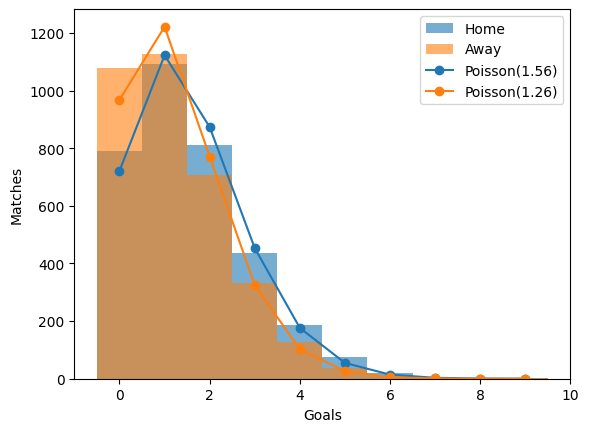

In [13]:
max_goals = int(max(matches["FTHG"].max(), matches["FTAG"].max()))
bins = np.arange(0, max_goals + 2) - 0.5
k = np.arange(0, max_goals + 1)
n = len(matches)

def poisson_counts(avg, ks, n): # compute poisson dists based on means
    p = np.empty(len(ks))
    p[0] = np.exp(-avg)
    for i in range(1, len(ks)):
        p[i] = p[i - 1] * avg / i
    return n * p

home = matches["FTHG"].mean()
away = matches["FTAG"].mean()

fig, ax = plt.subplots()
ax.hist(matches["FTHG"], bins=bins, alpha=0.6, label="Home")
ax.hist(matches["FTAG"], bins=bins, alpha=0.6, label="Away")
ax.plot(k, poisson_counts(home, k, n), "o-", color="C0", label=f"Poisson({home:.2f})")
ax.plot(k, poisson_counts(away, k, n), "o-", color="C1", label=f"Poisson({away:.2f})")
ax.set_xlabel("Goals")
ax.set_ylabel("Matches")
ax.legend()
plt.show()

# notice that the data models poisson distribution 